# Data Analysis


1. Authenticate the Colab environment and download a sample TF Record file from the Waymo open dataset bucket.



In [ ]:
import os
# The Waymo package is built for TF 2.12. Colab defaults to Keras 3.
# This version mismatch causes CUDA context crashes. We must force Keras 2.
os.environ["TF_USE_LEGACY_KERAS"] = "1"

from google.colab import auth
import tensorflow as tf

# Enable GPU memory growth BEFORE any TF operations
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU Memory Growth Enabled")
    except RuntimeError as e:
        print(e)

auth.authenticate_user()
print('Authenticated')

# Get a list of all TFRecord file paths from the training bucket
train_bucket_pattern = 'gs://waymo_open_dataset_motion_v_1_3_1/uncompressed/scenario/training/*.tfrecord*'
train_files = tf.io.gfile.glob(train_bucket_pattern)

print(f'Number of training files found: {len(train_files)}')


Authenticated
Number of training files found: 1000


2. Install the Waymo open dataset package, load the downloaded TFRecord file, and parse a scenario protocol buffer to extract tracks and map features.

In [ ]:
!pip install waymo-open-dataset-tf-2-12-0 --no-deps
print('Installed Waymo open dataset package')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 36.3 MB/s eta 0:00:00
Installed Waymo open dataset package


In [ ]:
import tensorflow as tf
from waymo_open_dataset.protos import scenario_pb2

# Load the entire training dataset directly from GCS
dataset = tf.data.TFRecordDataset(train_files)

# Extract and parse the first record to verify
scenario = scenario_pb2.Scenario()
for record in dataset.take(1):
    scenario.ParseFromString(record.numpy())

# Print basic information
print(f'Scenario ID: {scenario.scenario_id}')
print(f'Number of tracks: {len(scenario.tracks)}')
print(f'Number of map features: {len(scenario.map_features)}')


Scenario ID: 28fe360951cf98d6
Number of tracks: 16
Number of map features: 257


3. Create visualizations using matplotlib to plot the road network map and the past/future trajectories of the agents in the parsed scenario.

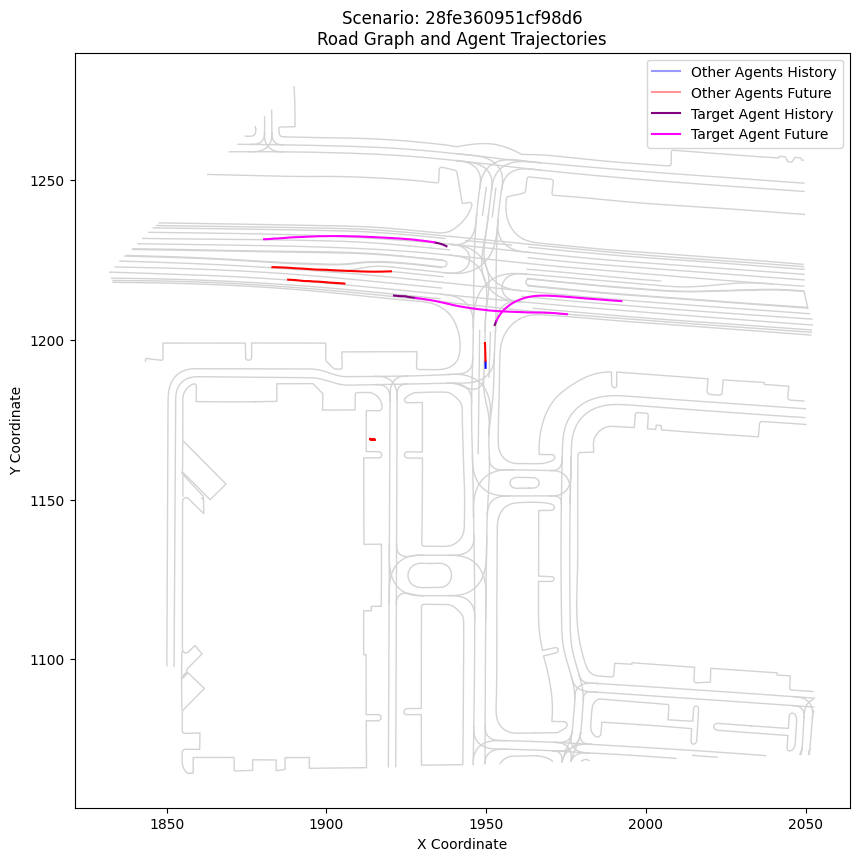

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# Create a new plot figure
fig, ax = plt.subplots(figsize=(10, 10))

# Visualize the road graph (lightgray)
for map_feature in scenario.map_features:
    # Map features can be lanes, road lines, road edges, etc.
    feature_type = map_feature.WhichOneof('feature_data')
    if feature_type:
        feature_data = getattr(map_feature, feature_type)
        if hasattr(feature_data, 'polyline'):
            polyline = feature_data.polyline
            x = [point.x for point in polyline]
            y = [point.y for point in polyline]
            ax.plot(x, y, color='lightgray', linewidth=1)

# Identify the indices of agents we actually need to predict
predict_tracks = [t.track_index for t in scenario.tracks_to_predict]
# print(predict_tracks)

# Visualize the trajectories
for track_idx, track in enumerate(scenario.tracks):
    hist_x, hist_y = [], []
    fut_x, fut_y = [], []

    # Iterate through the states and separate history (<=10) and future (>10)
    for step_index, state in enumerate(track.states):
        if state.valid:
            if step_index <= 10:
                hist_x.append(state.center_x)
                hist_y.append(state.center_y)
            else:
                fut_x.append(state.center_x)
                fut_y.append(state.center_y)

    if hist_x or fut_x:
        # Highlight the agents we need to predict
        is_predict = track_idx in predict_tracks
        lw = 1.5
        alpha = 1.0

        hist_color = 'purple' if is_predict else 'blue'
        fut_color = 'magenta' if is_predict else 'red'

        # Plot History
        if hist_x:
            ax.plot(hist_x, hist_y, color=hist_color, linewidth=lw, alpha=alpha)
        # Plot Future
        if fut_x:
            ax.plot(fut_x, fut_y, color=fut_color, linewidth=lw, alpha=alpha)

# Add custom legend
custom_lines = [
    Line2D([0], [0], color='blue', lw=1.5, alpha=0.4),
    Line2D([0], [0], color='red', lw=1.5, alpha=0.4),
    Line2D([0], [0], color='purple', lw=1.5),
    Line2D([0], [0], color='magenta', lw=1.5)
]
ax.legend(custom_lines, ['Other Agents History', 'Other Agents Future', 'Target Agent History', 'Target Agent Future'])

# Add title and labels
ax.set_title(f'Scenario: {scenario.scenario_id}\nRoad Graph and Agent Trajectories')
ax.set_xlabel('X Coordinate')
ax.set_ylabel('Y Coordinate')

# Adjust aspect ratio so map proportions are correct
ax.set_aspect('equal')

# Display the plot
plt.show()

In [ ]:
import pandas as pd
from waymo_open_dataset.protos.scenario_pb2 import Track

# Map numeric object_type to string label
type_map = {
    Track.ObjectType.TYPE_UNSET: 'UNSET',
    Track.ObjectType.TYPE_VEHICLE: 'VEHICLE',
    Track.ObjectType.TYPE_PEDESTRIAN: 'PEDESTRIAN',
    Track.ObjectType.TYPE_CYCLIST: 'CYCLIST',
    Track.ObjectType.TYPE_OTHER: 'OTHER'
}

# Extract data from the already parsed 'scenario' object
data = []

for track in scenario.tracks:
    agent_id = track.id
    agent_type = type_map.get(track.object_type, 'UNKNOWN')

    for step_index, state in enumerate(track.states):
        row = {
            'agent_id': agent_id,
            'agent_type': agent_type,
            'time_step': step_index, # 0 to 90 (9.1 seconds at 10Hz)
            'valid': state.valid,    # Whether the agent was observed at this step
            'center_x': state.center_x,
            'center_y': state.center_y,
            'center_z': state.center_z,
            'length': state.length,
            'width': state.width,
            'height': state.height,
            'heading': state.heading,
            'velocity_x': state.velocity_x,
            'velocity_y': state.velocity_y
        }
        data.append(row)

# Create a pandas DataFrame
df_scenario = pd.DataFrame(data)

# agent's first 15 time steps
display(df_scenario.head(15))

# Print a summary of the columns (attributes)
# print("\nDataFrame Summary:")
# df_scenario.info()

,agent_id,agent_type,time_step,valid,center_x,center_y,center_z,length,width,height,heading,velocity_x,velocity_y
0,0,VEHICLE,0,True,1952.715942,1204.631348,-11.122221,5.491659,2.520635,1.991279,1.317218,0.334473,1.099854
1,0,VEHICLE,1,True,1952.746460,1204.729126,-11.119348,5.484629,2.521022,1.993847,1.320462,0.305176,0.977783
2,0,VEHICLE,2,True,1952.791382,1204.846069,-11.117373,5.456868,2.517166,1.989331,1.309195,0.449219,1.169434
3,0,VEHICLE,3,True,1952.827393,1204.948486,-11.116808,5.472248,2.518151,1.994251,1.299357,0.360107,1.024170
4,0,VEHICLE,4,True,1952.873047,1205.060669,-11.117710,5.478967,2.513201,1.997603,1.290896,0.456543,1.121826
5,0,VEHICLE,5,True,1952.918213,1205.178101,-11.116179,5.474614,2.515145,2.000176,1.281944,0.451660,1.174316
6,0,VEHICLE,6,True,1952.961060,1205.302124,-11.113897,5.487998,2.514387,2.009244,1.283490,0.428467,1.240234
7,0,VEHICLE,7,True,1953.010986,1205.416016,-11.116613,5.485196,2.520515,2.005066,1.268673,0.499268,1.138916
8,0,VEHICLE,8,True,1953.059937,1205.537476,-11.119132,5.516205,2.521922,2.007560,1.254097,0.489502,1.214600
9,0,VEHICLE,9,True,1953.118164,1205.668823,-11.120478,5.523455,2.519682,2.012224,1.243470,0.582275,1.313477


In [ ]:
from waymo_open_dataset.protos import scenario_pb2
from waymo_open_dataset.protos import map_pb2

def print_protobuf_schema(message_class, title):
    print(f"\n=== {title} ===")
    # Extract all the field names from the protobuf descriptor
    fields = list(message_class.DESCRIPTOR.fields_by_name.keys())
    for field in fields:
        print(f" - {field}")

# Print the attributes for the main components of the dataset
print_protobuf_schema(scenario_pb2.Scenario, "SCENARIO (The 9-second clip)")
print_protobuf_schema(scenario_pb2.Track, "TRACK (An individual agent)")
print_protobuf_schema(scenario_pb2.ObjectState, "TRACK STATE (An agent at a specific 0.1s time step)")
print_protobuf_schema(map_pb2.MapFeature, "MAP FEATURE (A single static road element)")
print_protobuf_schema(scenario_pb2.DynamicMapState, "DYNAMIC MAP STATE (Traffic lights at a specific time step)")


=== SCENARIO (The 9-second clip) ===
 - scenario_id
 - timestamps_seconds
 - current_time_index
 - tracks
 - dynamic_map_states
 - map_features
 - sdc_track_index
 - objects_of_interest
 - tracks_to_predict
 - compressed_frame_laser_data
 - frame_camera_tokens

=== TRACK (An individual agent) ===
 - id
 - object_type
 - states

=== TRACK STATE (An agent at a specific 0.1s time step) ===
 - center_x
 - center_y
 - center_z
 - length
 - width
 - height
 - heading
 - velocity_x
 - velocity_y
 - valid

=== MAP FEATURE (A single static road element) ===
 - id
 - lane
 - road_line
 - road_edge
 - stop_sign
 - crosswalk
 - speed_bump
 - driveway

=== DYNAMIC MAP STATE (Traffic lights at a specific time step) ===
 - lane_states


## Scalable Data Pipeline for Transformer Training

To process hundreds of thousands of scenarios from the entire training bucket, we cannot load all data into memory at once.
Here, we define a Python generator that processes scenarios on-the-fly and wrap it in a `tf.data.Dataset`. This pipeline extracts the exact same historical, map, and future features, but pads the map points to a fixed size so the tensors can be batched for deep learning.

In [ ]:
import numpy as np
import tensorflow as tf
from waymo_open_dataset.protos import scenario_pb2

def extract_scenario_features(scenario, max_map_points=1000):
    """Processes a single scenario and extracts features for valid agents."""
    allowed_types = [scenario_pb2.Track.ObjectType.TYPE_VEHICLE,
                     scenario_pb2.Track.ObjectType.TYPE_PEDESTRIAN,
                     scenario_pb2.Track.ObjectType.TYPE_CYCLIST]

    # 1. Extract Map Points
    map_points = []
    for map_feature in scenario.map_features:
        feature_type = map_feature.WhichOneof('feature_data')
        if feature_type:
            feature_data = getattr(map_feature, feature_type)
            if hasattr(feature_data, 'polyline'):
                for point in feature_data.polyline:
                    map_points.append([point.x, point.y])
    map_points_array = np.array(map_points) if map_points else np.empty((0, 2))

    agents_hist = []
    agents_map = []
    agents_fut = []

    # 2. Process Tracks
    for track in scenario.tracks:
        if track.object_type not in allowed_types:
            continue

        states = track.states
        if len(states) < 91:
            continue

        # Check validity (0-10 must be valid, 90 must be valid)
        if not all(states[i].valid for i in range(11)) or not states[90].valid:
            continue

        # Reference state at t=10
        ref_state = states[10]
        ref_x, ref_y, ref_heading = ref_state.center_x, ref_state.center_y, ref_state.heading
        cos_h, sin_h = np.cos(-ref_heading), np.sin(-ref_heading)

        # Extract History (0-10)
        hist_features = np.zeros((11, 7)) # local_x, local_y, local_heading, speed, accel, yaw_rate, dist_map
        speeds = []
        for i in range(11):
            s = states[i]
            dx, dy = s.center_x - ref_x, s.center_y - ref_y
            local_x = dx * cos_h - dy * sin_h
            local_y = dx * sin_h + dy * cos_h
            local_heading = s.heading - ref_heading
            speed = np.sqrt(s.velocity_x**2 + s.velocity_y**2)
            speeds.append(speed)

            hist_features[i, :4] = [local_x, local_y, local_heading, speed]

        # Kinematics
        for i in range(1, 11):
            hist_features[i, 4] = (speeds[i] - speeds[i-1]) / 0.1 # accel
            dh = states[i].heading - states[i-1].heading
            dh = (dh + np.pi) % (2 * np.pi) - np.pi
            hist_features[i, 5] = dh / 0.1 # yaw rate

        # Nearest Map Distance
        if len(map_points_array) > 0:
            dists = np.linalg.norm(map_points_array - np.array([ref_x, ref_y]), axis=1)
            min_dist = np.min(dists)
        else:
            min_dist = 0.0
        hist_features[:, 6] = min_dist

        # Extract Future (11-90)
        fut_features = np.zeros((80, 2))
        for i in range(11, 91):
            s = states[i]
            dx, dy = s.center_x - ref_x, s.center_y - ref_y
            local_x = dx * cos_h - dy * sin_h
            local_y = dx * sin_h + dy * cos_h
            fut_features[i-11] = [local_x, local_y]

        # Transform Map to Agent-Centric
        if len(map_points_array) > 0:
            dx_map = map_points_array[:, 0] - ref_x
            dy_map = map_points_array[:, 1] - ref_y
            local_map_x = dx_map * cos_h - dy_map * sin_h
            local_map_y = dx_map * sin_h + dy_map * cos_h
            local_map = np.stack([local_map_x, local_map_y], axis=1)
        else:
            local_map = np.zeros((0, 2))

        # Pad or truncate map points to fixed size for batching
        if len(local_map) > max_map_points:
            # Optional: sort by distance to origin and take closest
            dists = np.linalg.norm(local_map, axis=1)
            closest_idx = np.argsort(dists)[:max_map_points]
            local_map = local_map[closest_idx]
        elif len(local_map) < max_map_points:
            pad_size = max_map_points - len(local_map)
            local_map = np.pad(local_map, ((0, pad_size), (0, 0)), mode='constant')

        agents_hist.append(hist_features)
        agents_map.append(local_map)
        agents_fut.append(fut_features)

    return agents_hist, agents_map, agents_fut

def waymo_generator(file_paths, max_scenarios=None):
    """Generator that yields (inputs, targets) for each valid agent."""
    dataset = tf.data.TFRecordDataset(file_paths)
    scenario_count = 0

    for record in dataset:
        if max_scenarios and scenario_count >= max_scenarios:
            break

        scenario = scenario_pb2.Scenario()
        scenario.ParseFromString(record.numpy())

        hists, maps, futs = extract_scenario_features(scenario)

        for h, m, f in zip(hists, maps, futs):
            # Yield inputs dict and target array
            yield {'history': h, 'map_context': m}, f

        scenario_count += 1


In [ ]:
# --- CONFIGURATION TOGGLE ---
# The full dataset (1000 files) takes far too long on a CPU.
# Let's use a 5% subset (50 files) to get good results in a fraction of the time.
NUM_FILES_TO_USE = 100
subset_train_files = train_files[:NUM_FILES_TO_USE]

# Standard ML Batch Size
BATCH_SIZE = 64

output_signature = (
    {
        'history': tf.TensorSpec(shape=(11, 7), dtype=tf.float32),
        'map_context': tf.TensorSpec(shape=(1000, 2), dtype=tf.float32)
    },
    tf.TensorSpec(shape=(80, 2), dtype=tf.float32) # Future targets
)

# Create dataset from the subset of files
train_dataset = tf.data.Dataset.from_generator(
    lambda: waymo_generator(subset_train_files, max_scenarios=None),
    output_signature=output_signature
)

# Batch and prefetch for performance
train_dataset = train_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Test the pipeline
for inputs, targets in train_dataset.take(1):
    print("Batched History Shape:", inputs['history'].shape)
    print("Batched Map Context Shape:", inputs['map_context'].shape)
    print("Batched Future Targets Shape:", targets.shape)
    print(f"Dataset is ready! Using {NUM_FILES_TO_USE} files instead of all {len(train_files)}.")

Batched History Shape: (64, 11, 7)
Batched Map Context Shape: (64, 1000, 2)
Batched Future Targets Shape: (64, 80, 2)
Dataset is ready! Using 100 files instead of all 1000.


Primary attributes to use:
* **Inputs (History):** You will typically use `time_step` 0 through 10. The features `center_x`, `center_y`, `velocity_x`, `velocity_y`, `heading`, and bounding box sizes (`length`, `width`) act as your model inputs.

* **Outputs (Future/Target):** You will try to predict the `center_x` and `center_y` (and sometimes `heading`) for `time_step` 11 through 90.
* **Validity:** The `valid` flag is crucial. You should only calculate loss or extract features when `valid == True`.

## Dataset Analysis and Feature Selection


1. Analyze the features within the parsed scenario, such as agent types and track lengths, to prepare for feature extraction and modeling.


In [ ]:
from collections import Counter
import numpy as np
from waymo_open_dataset.protos.scenario_pb2 import Track

# Map numeric object_type to string label
type_map = {
    Track.ObjectType.TYPE_UNSET: 'UNSET',
    Track.ObjectType.TYPE_VEHICLE: 'VEHICLE',
    Track.ObjectType.TYPE_PEDESTRIAN: 'PEDESTRIAN',
    Track.ObjectType.TYPE_CYCLIST: 'CYCLIST',
    Track.ObjectType.TYPE_OTHER: 'OTHER'
}

agent_types = []
track_lengths = []

for track in scenario.tracks:
    agent_types.append(type_map.get(track.object_type, 'UNKNOWN'))
    valid_states = sum(1 for state in track.states if state.valid)
    track_lengths.append(valid_states)

# Count agent types
type_counts = Counter(agent_types)
print('Agent Type Distribution:')
for agent_type, count in type_counts.items():
    print(f'  {agent_type}: {count}')

# Track length statistics
print('\nTrack Length Statistics (Valid States):')
print(f'  Min: {np.min(track_lengths)}')
print(f'  Max: {np.max(track_lengths)}')
print(f'  Mean: {np.mean(track_lengths):.2f}')


Agent Type Distribution:
  VEHICLE: 15
  CYCLIST: 1

Track Length Statistics (Valid States):
  Min: 7
  Max: 91
  Mean: 68.62


### Data Filtering
Applying filters for valid history, valid future targets, and specific agent types.

In [ ]:
# 1. Filter out unwanted agent types (Keep only Vehicles, Pedestrians, Cyclists)
allowed_types = ['VEHICLE', 'PEDESTRIAN', 'CYCLIST']
df_filtered = df_scenario[df_scenario['agent_type'].isin(allowed_types)]

valid_agent_ids = []

# Group by agent to evaluate their track length and validity
for agent_id, group in df_filtered.groupby('agent_id'):
    # Split into history (0-10) and future (11-90)
    history = group[group['time_step'] <= 10]
    future = group[group['time_step'] > 10]

    # Condition A: Must have a fully valid history (11 frames)
    has_full_history = history['valid'].all() and len(history) == 11

    # Condition B: Must have a valid final target (step 90) to ensure a long future track
    has_final_target = future[(future['time_step'] == 90) & (future['valid'] == True)].any().any()

    if has_full_history and has_final_target:
        valid_agent_ids.append(agent_id)

# Apply the final filter to keep only fully qualified agents
df_training_ready = df_filtered[df_filtered['agent_id'].isin(valid_agent_ids)]

print(f"Original rows: {len(df_scenario)} | Original agents: {df_scenario['agent_id'].nunique()}")
print(f"Filtered rows: {len(df_training_ready)} | Qualified agents: {len(valid_agent_ids)}")
print(f"Agents ready for training: {valid_agent_ids}")

# Preview the cleaned data for the first qualified agent
if valid_agent_ids:
    display(df_training_ready[df_training_ready['agent_id'] == valid_agent_ids[0]].head())

Original rows: 1456 | Original agents: 16
Filtered rows: 819 | Qualified agents: 9
Agents ready for training: [0, 2, 3, 4, 5, 6, 11, 12, 142]


,agent_id,agent_type,time_step,valid,center_x,center_y,center_z,length,width,height,heading,velocity_x,velocity_y
0,0,VEHICLE,0,True,1952.715942,1204.631348,-11.122221,5.491659,2.520635,1.991279,1.317218,0.334473,1.099854
1,0,VEHICLE,1,True,1952.746460,1204.729126,-11.119348,5.484629,2.521022,1.993847,1.320462,0.305176,0.977783
2,0,VEHICLE,2,True,1952.791382,1204.846069,-11.117373,5.456868,2.517166,1.989331,1.309195,0.449219,1.169434
3,0,VEHICLE,3,True,1952.827393,1204.948486,-11.116808,5.472248,2.518151,1.994251,1.299357,0.360107,1.024170
4,0,VEHICLE,4,True,1952.873047,1205.060669,-11.117710,5.478967,2.513201,1.997603,1.290896,0.456543,1.121826


### Feature Engineering
Feature engineering pipeline for the filtered Waymo dataset tracks:
1. transform the absolute map coordinates into agent-centric local coordinates,
2. extract kinematic features (such as speed, acceleration, and yaw rate) from the historical data
3. integrate map context features (such as distance from the road) from the surrounding road graph
4. format these engineered features into standardized tensors suitable for deep learning and summarize the resulting tensor shapes

### Agent-Centric Coordinate Transformation
Transform absolute map coordinates into agent-centric local coordinates based on the agent's position and heading at time step 10.


In [ ]:
import numpy as np

def transform_to_agent_centric(df):
    df_transformed = df.copy()
    df_transformed['local_x'] = 0.0
    df_transformed['local_y'] = 0.0
    df_transformed['local_heading'] = 0.0

    for agent_id, group in df_transformed.groupby('agent_id'):
        # Get reference state at time_step 10
        ref_state = group[group['time_step'] == 10]
        if ref_state.empty:
            continue

        ref_x = ref_state['center_x'].values[0]
        ref_y = ref_state['center_y'].values[0]
        ref_heading = ref_state['heading'].values[0]

        # Get indices for this agent
        idx = group.index

        # Translate
        dx = df_transformed.loc[idx, 'center_x'] - ref_x
        dy = df_transformed.loc[idx, 'center_y'] - ref_y

        # Rotate
        cos_h = np.cos(-ref_heading)
        sin_h = np.sin(-ref_heading)

        df_transformed.loc[idx, 'local_x'] = dx * cos_h - dy * sin_h
        df_transformed.loc[idx, 'local_y'] = dx * sin_h + dy * cos_h
        df_transformed.loc[idx, 'local_heading'] = df_transformed.loc[idx, 'heading'] - ref_heading

    return df_transformed

df_training_ready = transform_to_agent_centric(df_training_ready)

# Display verification for time_step 10
display(df_training_ready[df_training_ready['time_step'] == 10][['agent_id', 'time_step', 'center_x', 'center_y', 'local_x', 'local_y', 'heading', 'local_heading']].head())

# Display general head
display(df_training_ready.head())

,agent_id,time_step,center_x,center_y,local_x,local_y,heading,local_heading
10,0,10,1953.181763,1205.798828,0.0,0.0,1.238432,0.0
192,2,10,1926.748047,1193.996948,0.0,-0.0,1.627307,0.0
283,3,10,1921.610596,1193.682617,0.0,-0.0,1.630895,0.0
374,4,10,1927.639893,1168.720825,0.0,0.0,6.242266,0.0
465,5,10,1916.531006,1194.255981,0.0,0.0,7.777323,0.0


,agent_id,agent_type,time_step,valid,center_x,center_y,center_z,length,width,height,heading,velocity_x,velocity_y,local_x,local_y,local_heading
0,0,VEHICLE,0,True,1952.715942,1204.631348,-11.122221,5.491659,2.520635,1.991279,1.317218,0.334473,1.099854,-1.255576,0.059403,0.078786
1,0,VEHICLE,1,True,1952.746460,1204.729126,-11.119348,5.484629,2.521022,1.993847,1.320462,0.305176,0.977783,-1.153191,0.062459,0.082030
2,0,VEHICLE,2,True,1952.791382,1204.846069,-11.117373,5.456868,2.517166,1.989331,1.309195,0.449219,1.169434,-1.027991,0.058151,0.070763
3,0,VEHICLE,3,True,1952.827393,1204.948486,-11.116808,5.472248,2.518151,1.994251,1.299357,0.360107,1.024170,-0.919429,0.057528,0.060925
4,0,VEHICLE,4,True,1952.873047,1205.060669,-11.117710,5.478967,2.513201,1.997603,1.290896,0.456543,1.121826,-0.798490,0.050975,0.052464


## Kinematic Feature Extraction

Calculate advanced kinematic features from the historical track data (time steps 0-10).


In [ ]:
def calculate_kinematic_features(df):
    df_k = df.copy()
    dt = 0.1 # 10Hz data

    # Calculate speed (magnitude of velocity vector)
    df_k['speed'] = np.sqrt(df_k['velocity_x']**2 + df_k['velocity_y']**2)

    # Initialize acceleration and yaw_rate
    df_k['acceleration'] = 0.0
    df_k['yaw_rate'] = 0.0

    for agent_id, group in df_k.groupby('agent_id'):
        idx = group.index

        # Acceleration: dv/dt
        speed_diff = group['speed'].diff()
        speed_diff.iloc[0] = 0.0 # Handle first element
        df_k.loc[idx, 'acceleration'] = speed_diff / dt

        # Yaw rate: d(heading)/dt
        # Need to handle angle wrapping, but for simplicity here we just take the diff
        heading_diff = group['heading'].diff()
        heading_diff.iloc[0] = 0.0

        # Adjust for wrapping between -pi and pi
        heading_diff = (heading_diff + np.pi) % (2 * np.pi) - np.pi

        df_k.loc[idx, 'yaw_rate'] = heading_diff / dt

    return df_k

# Apply only to historical data (steps 0-10) or compute for all and filter if needed later.
# The instructions say "Apply these calculations to the historical data (time steps 0-10) and append..."
# It's usually easier to compute for all valid steps. Let's compute for all and then we can look at 0-10.
df_training_ready = calculate_kinematic_features(df_training_ready)

# Display sample of historical steps
display(df_training_ready[df_training_ready['time_step'] <= 10][['agent_id', 'time_step', 'speed', 'acceleration', 'yaw_rate']].head(15))


,agent_id,time_step,speed,acceleration,yaw_rate
0,0,0,1.149587,0.000000,0.000000
1,0,1,1.024301,-1.252859,0.032437
2,0,2,1.252746,2.284451,-0.112669
3,0,3,1.085634,-1.671119,-0.098373
4,0,4,1.211167,1.255329,-0.084617
5,0,5,1.258180,0.470126,-0.089519
6,0,6,1.312160,0.539809,0.015464
7,0,7,1.243542,-0.686180,-0.148171
8,0,8,1.309528,0.659859,-0.145762
9,0,9,1.436755,1.272268,-0.106267


## Map Context Integration

Extract spatial relationships by computing the relative distance from each agent to the nearest map feature, in agent's reference position (time_step 10).


In [ ]:
import numpy as np

# 1 & 2. Collect map points
map_points = []
for map_feature in scenario.map_features:
    feature_type = map_feature.WhichOneof('feature_data')
    if feature_type:
        feature_data = getattr(map_feature, feature_type)
        if hasattr(feature_data, 'polyline'):
            for point in feature_data.polyline:
                map_points.append([point.x, point.y])

map_points_array = np.array(map_points)

# 3. Initialize column
df_training_ready['dist_to_nearest_map'] = 0.0

# 4, 5 & 6. Calculate distances and assign
for agent_id, group in df_training_ready.groupby('agent_id'):
    ref_state = group[group['time_step'] == 10]
    if ref_state.empty:
        continue

    ref_x = ref_state['center_x'].values[0]
    ref_y = ref_state['center_y'].values[0]

    # Calculate Euclidean distances
    if len(map_points_array) > 0:
        distances = np.linalg.norm(map_points_array - np.array([ref_x, ref_y]), axis=1)
        min_dist = np.min(distances)
    else:
        min_dist = np.nan # Or 0.0 if no map features

    df_training_ready.loc[group.index, 'dist_to_nearest_map'] = min_dist

# 7. Display verification
display(df_training_ready[['agent_id', 'time_step', 'dist_to_nearest_map']].head(15))


,agent_id,time_step,dist_to_nearest_map
0,0,0,0.124269
1,0,1,0.124269
2,0,2,0.124269
3,0,3,0.124269
4,0,4,0.124269
5,0,5,0.124269
6,0,6,0.124269
7,0,7,0.124269
8,0,8,0.124269
9,0,9,0.124269


## Format Tensors for Deep Learning

Structure the engineered historical features, map context features, and future target coordinates into standardized NumPy arrays suitable for training a deep learning model.


In [ ]:
import numpy as np

# Define the list of historical feature column names to extract
historical_features = ['local_x', 'local_y', 'local_heading', 'speed', 'acceleration', 'yaw_rate', 'dist_to_nearest_map']

history_tensors = []
future_tensors = []

# Iterate through each unique agent_id in df_training_ready
for agent_id in df_training_ready['agent_id'].unique():
    agent_data = df_training_ready[df_training_ready['agent_id'] == agent_id]

    # Extract historical features for time steps 0 to 10
    history_data = agent_data[agent_data['time_step'] <= 10]
    # Ensure we have exactly 11 steps and order them by time_step
    history_data = history_data.sort_values('time_step')

    if len(history_data) == 11:
        history_array = history_data[historical_features].values
        history_tensors.append(history_array)

        # Extract future target coordinates (local_x, local_y) for time steps 11 to 90
        future_data = agent_data[(agent_data['time_step'] > 10) & (agent_data['time_step'] <= 90)]
        future_data = future_data.sort_values('time_step')

        # Ensure we have exactly 80 future steps
        if len(future_data) == 80:
            future_array = future_data[['local_x', 'local_y']].values
            future_tensors.append(future_array)
        else:
            # If future data is missing, we shouldn't append history to keep them aligned
            history_tensors.pop()

# Convert lists to NumPy arrays
history_tensor_np = np.array(history_tensors)
future_tensor_np = np.array(future_tensors)

# Print shapes to verify
print(f"Historical features tensor shape: {history_tensor_np.shape}")
print(f"Future targets tensor shape: {future_tensor_np.shape}")

Historical features tensor shape: (9, 11, 7)
Future targets tensor shape: (9, 80, 2)


## Implement Map Coordinate Transformation

Transforming map features into individual agent-centric coordinate frames to provide richer spatial context for prediction models - apply the same translation and rotation logic (agen't reference at time step 10)


In [ ]:
import numpy as np

def transform_map_to_agent_centric(df, map_points):
    transformed_maps = {}
    for agent_id, group in df.groupby('agent_id'):
        ref_state = group[group['time_step'] == 10]
        if ref_state.empty:
            continue

        ref_x = ref_state['center_x'].values[0]
        ref_y = ref_state['center_y'].values[0]
        ref_heading = ref_state['heading'].values[0]

        # Translate
        dx = map_points[:, 0] - ref_x
        dy = map_points[:, 1] - ref_y

        # Rotate
        cos_h = np.cos(-ref_heading)
        sin_h = np.sin(-ref_heading)

        local_x = dx * cos_h - dy * sin_h
        local_y = dx * sin_h + dy * cos_h

        transformed_maps[agent_id] = np.stack([local_x, local_y], axis=1)

    return transformed_maps

# map_points_array was calculated in a previous cell
agent_centric_maps = transform_map_to_agent_centric(df_training_ready, map_points_array)

# Display sample for the first agent
first_agent_id = list(agent_centric_maps.keys())[0]
print(f"Sample of transformed map points for agent {first_agent_id}:")
print(agent_centric_maps[first_agent_id][:5])

Sample of transformed map points for agent 0:
[[ 79.00095854 -74.363112  ]
 [ 78.87996889 -73.89640852]
 [ 79.13381772 -73.69641509]
 [ 79.38766654 -73.49642166]
 [ 79.29944006 -73.02822085]]


## Refine Feature Tensor Creation

Refine the feature tensor creation logic to include the newly transformed local map coordinates for each agent.

In [ ]:
import numpy as np

historical_features = ['local_x', 'local_y', 'local_heading', 'speed', 'acceleration', 'yaw_rate', 'dist_to_nearest_map']

history_tensors = []
future_tensors = []
map_tensors = []

for agent_id in df_training_ready['agent_id'].unique():
    agent_data = df_training_ready[df_training_ready['agent_id'] == agent_id]

    history_data = agent_data[agent_data['time_step'] <= 10].sort_values('time_step')

    if len(history_data) == 11:
        future_data = agent_data[(agent_data['time_step'] > 10) & (agent_data['time_step'] <= 90)].sort_values('time_step')

        if len(future_data) == 80:
            history_tensors.append(history_data[historical_features].values)
            future_tensors.append(future_data[['local_x', 'local_y']].values)

            if agent_id in agent_centric_maps:
                map_tensors.append(agent_centric_maps[agent_id])

history_tensor_np = np.array(history_tensors)
future_tensor_np = np.array(future_tensors)
map_tensor_np = np.array(map_tensors)

print(f"Historical features tensor shape: {history_tensor_np.shape}")
print(f"Future targets tensor shape: {future_tensor_np.shape}")
print(f"Map context tensor shape: {map_tensor_np.shape}")

Historical features tensor shape: (9, 11, 7)
Future targets tensor shape: (9, 80, 2)
Map context tensor shape: (9, 17969, 2)


## Visualize Coordinate Systems

Create side-by-side scatter plots comparing the original global map and trajectory coordinates with the transformed agent-centric coordinates for a specific target agent.


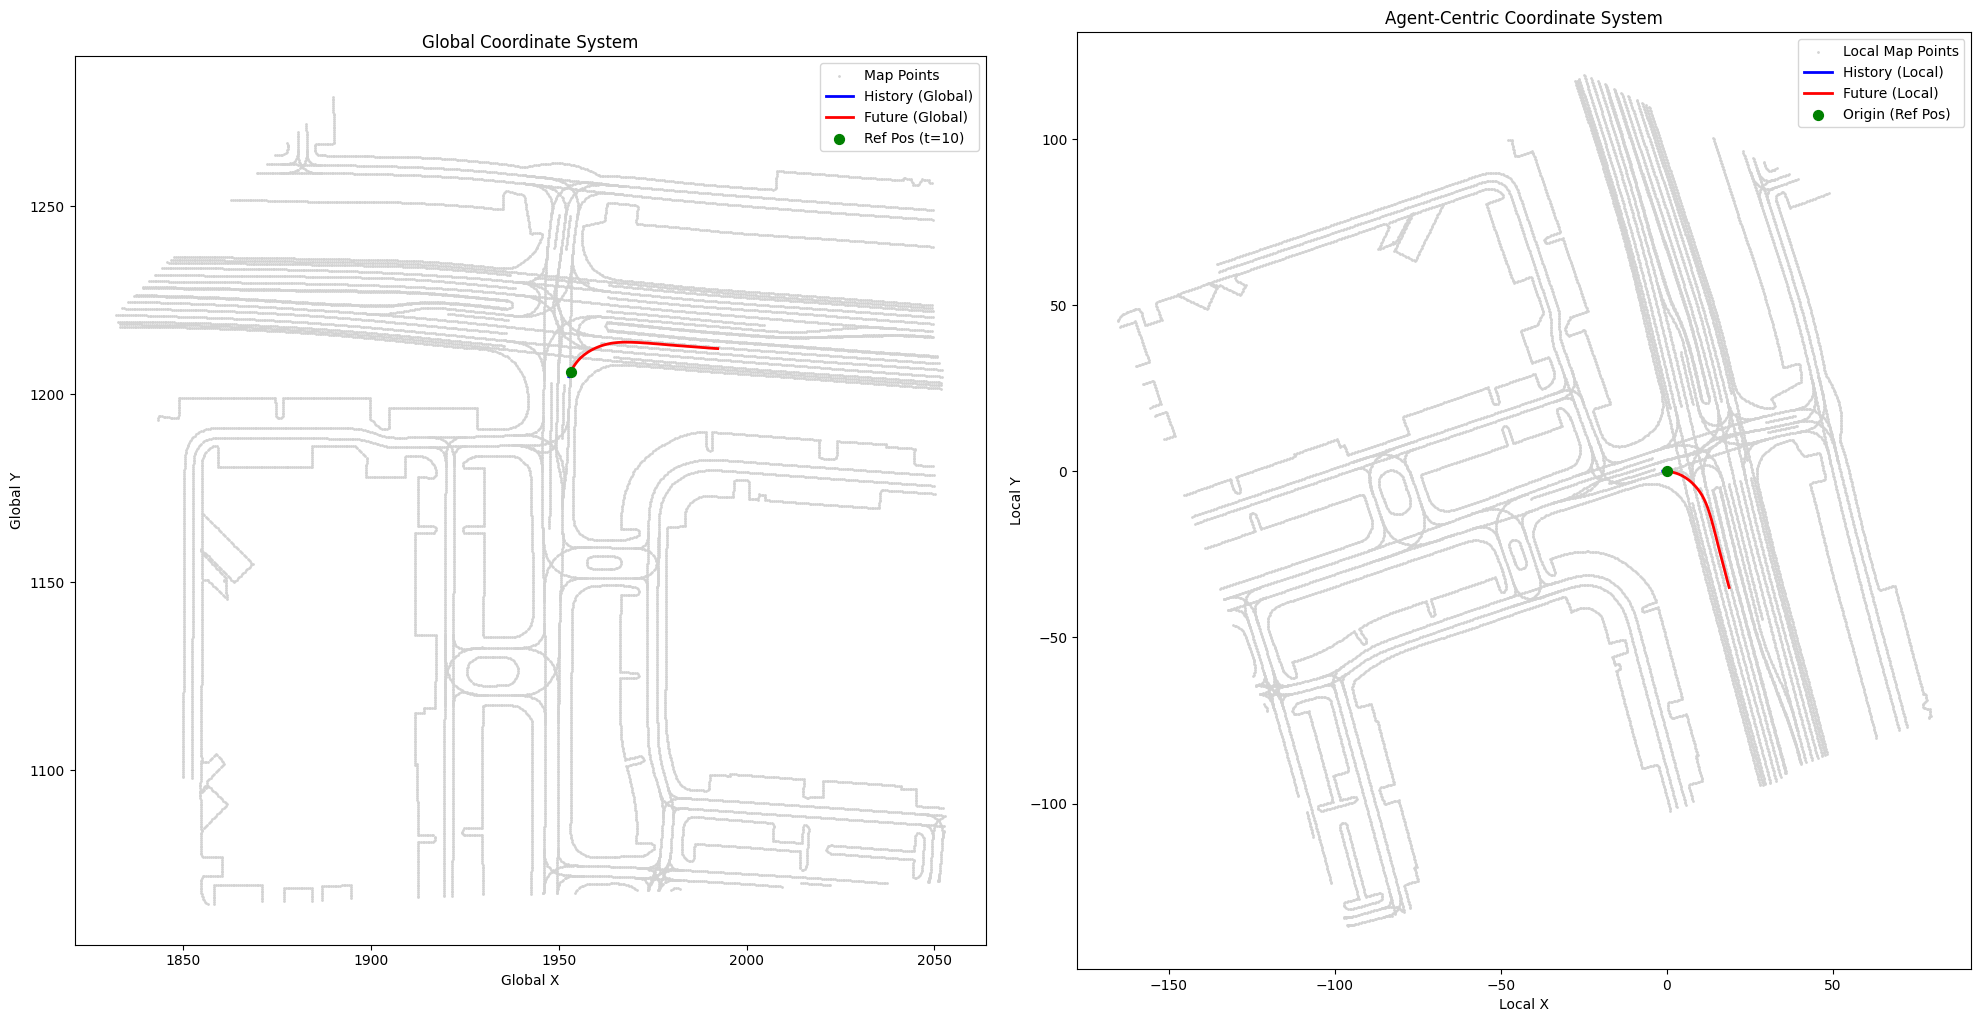

In [ ]:
import matplotlib.pyplot as plt

# Select target agent
target_agent_id = 0

# Extract agent trajectory data
agent_df = df_training_ready[df_training_ready['agent_id'] == target_agent_id]
hist_df = agent_df[agent_df['time_step'] <= 10]
fut_df = agent_df[agent_df['time_step'] > 10]

# Extract map data
global_map = map_points_array
local_map = agent_centric_maps[target_agent_id]

# Create figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

# Plot Global Coordinate System
ax1.scatter(global_map[:, 0], global_map[:, 1], color='lightgray', s=1, label='Map Points')
ax1.plot(hist_df['center_x'], hist_df['center_y'], color='blue', linewidth=2, label='History (Global)')
ax1.plot(fut_df['center_x'], fut_df['center_y'], color='red', linewidth=2, label='Future (Global)')
ax1.scatter(hist_df[hist_df['time_step'] == 10]['center_x'], hist_df[hist_df['time_step'] == 10]['center_y'], color='green', s=50, label='Ref Pos (t=10)', zorder=5)
ax1.set_title('Global Coordinate System')
ax1.set_xlabel('Global X')
ax1.set_ylabel('Global Y')
ax1.set_aspect('equal')
ax1.legend()

# Plot Agent-Centric Coordinate System
ax2.scatter(local_map[:, 0], local_map[:, 1], color='lightgray', s=1, label='Local Map Points')
ax2.plot(hist_df['local_x'], hist_df['local_y'], color='blue', linewidth=2, label='History (Local)')
ax2.plot(fut_df['local_x'], fut_df['local_y'], color='red', linewidth=2, label='Future (Local)')
ax2.scatter(0, 0, color='green', s=50, label='Origin (Ref Pos)', zorder=5)
ax2.set_title('Agent-Centric Coordinate System')
ax2.set_xlabel('Local X')
ax2.set_ylabel('Local Y')
ax2.set_aspect('equal')
ax2.legend()

plt.tight_layout()
plt.show()

## Test - Access Validation Dataset

List and access the TFRecord files from the Waymo validation bucket directly via GCS.


In [ ]:
import tensorflow as tf

# 1. Retrieve a list of all TFRecord file paths from the validation bucket
val_bucket_pattern = 'gs://waymo_open_dataset_motion_v_1_3_1/uncompressed/scenario/validation/*.tfrecord*'
val_files = tf.io.gfile.glob(val_bucket_pattern)

# 3. Print the number of files found to verify successful access
print(f'Number of validation files found: {len(val_files)}')

# 2. Instantiate a tf.data.TFRecordDataset using the retrieved list of GCS file paths
val_dataset = tf.data.TFRecordDataset(val_files)


Number of validation files found: 150


In [ ]:
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm
from waymo_open_dataset.protos import scenario_pb2

val_data = []

type_map = {
    scenario_pb2.Track.ObjectType.TYPE_UNSET: 'UNSET',
    scenario_pb2.Track.ObjectType.TYPE_VEHICLE: 'VEHICLE',
    scenario_pb2.Track.ObjectType.TYPE_PEDESTRIAN: 'PEDESTRIAN',
    scenario_pb2.Track.ObjectType.TYPE_CYCLIST: 'CYCLIST',
    scenario_pb2.Track.ObjectType.TYPE_OTHER: 'OTHER'
}
allowed_types = ['VEHICLE', 'PEDESTRIAN', 'CYCLIST']

# 1 & 2. Parse scenarios from validation dataset
num_scenarios = 100
for record in tqdm(val_dataset.take(num_scenarios), total=num_scenarios, desc="Parsing Scenarios"):
    scenario = scenario_pb2.Scenario()
    scenario.ParseFromString(record.numpy())

    # 3. Extract and filter agents
    for track in scenario.tracks:
        agent_type = type_map.get(track.object_type, 'UNKNOWN')
        if agent_type not in allowed_types:
            continue

        states = track.states
        if len(states) < 91:
            continue

        # Check validity for full history and final target
        has_full_history = all(states[i].valid for i in range(11))
        has_final_target = states[90].valid

        if not (has_full_history and has_final_target):
            continue

        # Use a unique agent_id across scenarios
        unique_agent_id = f"{scenario.scenario_id}_{track.id}"

        # 5. Extract states
        for step_index, state in enumerate(states):
            if step_index > 90:
                break # Only need up to step 90
            row = {
                'scenario_id': scenario.scenario_id,
                'agent_id': unique_agent_id,
                'agent_type': agent_type,
                'time_step': step_index,
                'valid': state.valid,
                'center_x': state.center_x,
                'center_y': state.center_y,
                'heading': state.heading,
                'velocity_x': state.velocity_x,
                'velocity_y': state.velocity_y
            }
            val_data.append(row)

df_val_scenario = pd.DataFrame(val_data)
print(f"Extracted {df_val_scenario['agent_id'].nunique()} valid agents and {len(df_val_scenario)} valid rows for validation.")

# 4. Agent-Centric Coordinate Transformation
df_val_ready = df_val_scenario.copy()
df_val_ready['local_x'] = 0.0
df_val_ready['local_y'] = 0.0
df_val_ready['local_heading'] = 0.0

for agent_id, group in tqdm(df_val_ready.groupby('agent_id'), desc="Transforming Coordinates"):
    ref_state = group[group['time_step'] == 10]
    if ref_state.empty:
        continue

    ref_x = ref_state['center_x'].values[0]
    ref_y = ref_state['center_y'].values[0]
    ref_heading = ref_state['heading'].values[0]

    idx = group.index
    dx = df_val_ready.loc[idx, 'center_x'] - ref_x
    dy = df_val_ready.loc[idx, 'center_y'] - ref_y

    cos_h = np.cos(-ref_heading)
    sin_h = np.sin(-ref_heading)

    df_val_ready.loc[idx, 'local_x'] = dx * cos_h - dy * sin_h
    df_val_ready.loc[idx, 'local_y'] = dx * sin_h + dy * cos_h
    df_val_ready.loc[idx, 'local_heading'] = df_val_ready.loc[idx, 'heading'] - ref_heading

# Kinematic Feature Extraction
df_val_ready['speed'] = np.sqrt(df_val_ready['velocity_x']**2 + df_val_ready['velocity_y']**2)
df_val_ready['acceleration'] = 0.0
df_val_ready['yaw_rate'] = 0.0

dt = 0.1
for agent_id, group in tqdm(df_val_ready.groupby('agent_id'), desc="Extracting Kinematics"):
    idx = group.index

    # Acceleration
    speed_diff = group['speed'].diff()
    speed_diff.iloc[0] = 0.0
    df_val_ready.loc[idx, 'acceleration'] = speed_diff / dt

    # Yaw rate
    heading_diff = group['heading'].diff()
    heading_diff.iloc[0] = 0.0
    heading_diff = (heading_diff + np.pi) % (2 * np.pi) - np.pi
    df_val_ready.loc[idx, 'yaw_rate'] = heading_diff / dt

print("Feature engineering complete. Validation data ready.")
display(df_val_ready.head())

Parsing Scenarios:   0%|          | 0/100 [00:00<?, ?it/s]

Extracted 1832 valid agents and 166712 valid rows for validation.


Transforming Coordinates:   0%|          | 0/1832 [00:00<?, ?it/s]

Extracting Kinematics:   0%|          | 0/1832 [00:00<?, ?it/s]

Feature engineering complete. Validation data ready.


,scenario_id,agent_id,agent_type,time_step,valid,center_x,center_y,heading,velocity_x,velocity_y,local_x,local_y,local_heading,speed,acceleration,yaw_rate
0,b85e1bd6cc8e74c0,b85e1bd6cc8e74c0_1807,VEHICLE,0,True,3578.349121,4986.538086,-1.520831,1.086426,-21.406250,-21.218126,-0.066254,-0.007576,21.433802,0.000000,0.000000
1,b85e1bd6cc8e74c0,b85e1bd6cc8e74c0_1807,VEHICLE,1,True,3578.459717,4984.412109,-1.518627,1.105957,-21.259766,-19.089307,-0.078104,-0.005371,21.288513,-1.452891,0.022043
2,b85e1bd6cc8e74c0,b85e1bd6cc8e74c0_1807,VEHICLE,2,True,3578.583740,4982.276855,-1.515478,1.240234,-21.352539,-16.950455,-0.077082,-0.002222,21.388527,1.000147,0.031494
3,b85e1bd6cc8e74c0,b85e1bd6cc8e74c0_1807,VEHICLE,3,True,3578.707520,4980.156738,-1.512703,1.237793,-21.201172,-14.826728,-0.075433,0.000553,21.237274,-1.512531,0.027751
4,b85e1bd6cc8e74c0,b85e1bd6cc8e74c0_1807,VEHICLE,4,True,3578.834229,4978.032715,-1.512416,1.267090,-21.240234,-12.698933,-0.071084,0.000840,21.277995,0.407207,0.002867


Extract the future target trajectories from the prepared validation DataFrame and structure them into a NumPy tensor to be used as ground truth for evaluating the baseline models.



In [ ]:
import numpy as np

val_future_tensors = []
valid_agent_ids_val = []

for agent_id, agent_data in df_val_ready.groupby('agent_id'):
    # Extract future target coordinates (local_x, local_y) for time steps 11 to 90
    future_data = agent_data[(agent_data['time_step'] > 10) & (agent_data['time_step'] <= 90)].sort_values('time_step')

    # Ensure we have exactly 80 future steps
    if len(future_data) == 80:
        val_future_tensors.append(future_data[['local_x', 'local_y']].values)
        valid_agent_ids_val.append(agent_id)

val_future_tensor_np = np.array(val_future_tensors)

print(f"Validation valid agents count: {len(valid_agent_ids_val)}")
print(f"Validation future targets tensor shape: {val_future_tensor_np.shape}")

Validation valid agents count: 1832
Validation future targets tensor shape: (1832, 80, 2)


## Transformer Model

## Advanced: Cross-Attention (Agent-to-Map) with 10% train dataset
Instead of losing geometric information through Global Average Pooling, we use a **Cross-Attention** mechanism. The historical trajectory state acts as a query to attend to the encoded map points, allowing the model to dynamically extract relevant road features based on the agent's intended path.

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model

def build_improved_cross_attention_predictor(d_model=128, num_heads=4, ff_dim=256, dropout=0.1):
    # 1. Inputs
    history_input = layers.Input(shape=(11, 7), name='history')
    map_input = layers.Input(shape=(1000, 2), name='map_context')

    # 2. History Processing (LSTM + Self-Attention)
    # LSTM gives a strong temporal baseline before attention
    hist_lstm = layers.LSTM(d_model, return_sequences=True)(history_input)

    seq_len = 11
    positions = tf.range(start=0, limit=seq_len, delta=1)
    pos_emb = layers.Embedding(input_dim=seq_len, output_dim=d_model)(positions)
    hist_emb = hist_lstm + pos_emb

    hist_attn = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model, dropout=dropout)(hist_emb, hist_emb)
    hist_out = layers.LayerNormalization(epsilon=1e-6)(hist_emb + hist_attn)

    # 3. Map Processing (PointNet-style 1D Convs)
    # Using Conv1D treats the points independently but maps them to a higher dimensional space
    map_emb = layers.Conv1D(64, kernel_size=1, activation='relu')(map_input)
    map_emb = layers.Conv1D(128, kernel_size=1, activation='relu')(map_emb)
    map_emb = layers.Conv1D(d_model, kernel_size=1, activation='relu')(map_emb)

    # 4. Cross-Attention (Agent History attends to Map Geometry)
    # Query: Agent History, Key/Value: Map Features
    cross_attn = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model, dropout=dropout)(
        query=hist_out, value=map_emb, key=map_emb
    )
    fusion_out = layers.LayerNormalization(epsilon=1e-6)(hist_out + cross_attn)

    # Feed Forward Network
    ffn_output = layers.Dense(ff_dim, activation="relu")(fusion_out)
    ffn_output = layers.Dropout(dropout)(ffn_output)
    ffn_output = layers.Dense(d_model)(ffn_output)
    fusion_out = layers.LayerNormalization(epsilon=1e-6)(fusion_out + ffn_output)

    # 5. Output Head
    # Flatten the temporally-rich, map-aware sequence
    flat_context = layers.Flatten()(fusion_out)

    dense_out = layers.Dense(512, activation='relu')(flat_context)
    dense_out = layers.Dropout(dropout)(dense_out)
    dense_out = layers.Dense(256, activation='relu')(dense_out)
    dense_out = layers.Dense(160, activation='linear')(dense_out) # 80 steps * 2 (X, Y)

    # Reshape to target
    output = layers.Reshape((80, 2))(dense_out)

    model = Model(inputs=[history_input, map_input], outputs=output, name="Improved_CrossAttn_Predictor")
    return model

sota_model = build_improved_cross_attention_predictor()
sota_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.Huber(), # Huber loss is more robust to outliers than MSE
    metrics=['mae']
)
sota_model.summary()


Model: "Improved_CrossAttn_Predictor"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 history (InputLayer)        [(None, 11, 7)]              0         []                            
                                                                                                  
 lstm (LSTM)                 (None, 11, 128)              69632     ['history[0][0]']             
                                                                                                  
 tf.__operators__.add (TFOp  (None, 11, 128)              0         ['lstm[0][0]']                
 Lambda)                                                                                          
                                                                                                  
 map_context (InputLayer)    [(None, 1000, 2)]            0         [] 

In [19]:
import numpy as np
import tensorflow as tf

# 1. Update dataset to 10% (100 files)
NUM_FILES_10_PCT = 100
print(f"Setting up training dataset pipeline for {NUM_FILES_10_PCT} files (10% of training data)...")
subset_train_files_10 = train_files[:NUM_FILES_10_PCT]

train_dataset_10 = tf.data.Dataset.from_generator(
    lambda: waymo_generator(subset_train_files_10, max_scenarios=None),
    output_signature=output_signature
).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# 1.5 Setup validation dataset (next 20 files) - 2%
NUM_VAL_FILES = 20
print(f"Setting up validation dataset pipeline for {NUM_VAL_FILES} files...")
val_subset_files = train_files[NUM_FILES_10_PCT : NUM_FILES_10_PCT + NUM_VAL_FILES]

val_dataset_20 = tf.data.Dataset.from_generator(
    lambda: waymo_generator(val_subset_files, max_scenarios=None),
    output_signature=output_signature
).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# 2. Train the SOTA Cross-Attention model
EPOCHS = 5
print("\nStarting SOTA Cross-Attention Model Training with Validation")
history_sota = sota_model.fit(
    train_dataset_10,
    validation_data=val_dataset_20,
    epochs=EPOCHS
)
print("SOTA Training Complete!\n")

# 3. Save the model to Google Drive
save_path_sota = '/content/drive/MyDrive/waymo_sota_model_10percent.keras'
sota_model.save(save_path_sota)
print(f"Model successfully saved to '{save_path_sota}'!")

Setting up training dataset pipeline for 100 files (10% of training data)...
Setting up validation dataset pipeline for 20 files...

Starting SOTA Cross-Attention Model Training with Validation
Epoch 1/5
13854/13854 [==============================] - 14442s 1s/step - loss: 13.2525 - mae: 13.4094 - val_loss: 13.5449 - val_mae: 13.6988
Epoch 2/5
13854/13854 [==============================] - 14306s 1s/step - loss: 13.0611 - mae: 13.2055 - val_loss: 13.4409 - val_mae: 13.5851
Epoch 3/5
13854/13854 [==============================] - 14444s 1s/step - loss: 13.0221 - mae: 13.1634 - val_loss: 13.3729 - val_mae: 13.5162
Epoch 4/5
13854/13854 [==============================] - 14426s 1s/step - loss: 13.0053 - mae: 13.1452 - val_loss: 13.3653 - val_mae: 13.5066
Epoch 5/5
13854/13854 [==============================] - 14377s 1s/step - loss: 12.9921 - mae: 13.1309 - val_loss: 13.3851 - val_mae: 13.5231
SOTA Training Complete!



FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/waymo_sota_model_10percent.keras'

In [21]:
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Save the model to Google Drive
save_path_sota = '/content/drive/MyDrive/waymo_sota_model_10percent.keras'
sota_model.save(save_path_sota)
print(f"Model successfully saved to '{save_path_sota}'!")

Mounted at /content/drive
Model successfully saved to '/content/drive/MyDrive/waymo_sota_model_10percent.keras'!


## Evaluation & Plots

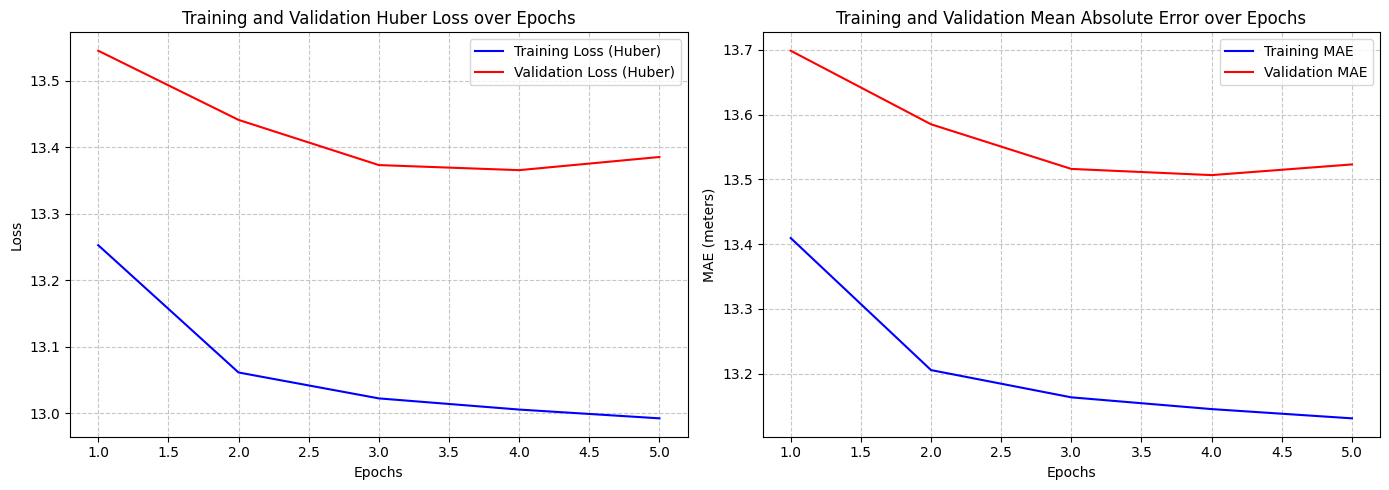

In [22]:
import matplotlib.pyplot as plt

if 'history_sota' in locals():
    # Extract the metrics from the history object
    loss = history_sota.history['loss']
    val_loss = history_sota.history.get('val_loss', [])
    mae = history_sota.history['mae']
    val_mae = history_sota.history.get('val_mae', [])
    epochs = range(1, len(loss) + 1)

    # Create a figure with two subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Plot Loss (Huber)
    ax1.plot(epochs, loss, 'b-', label='Training Loss (Huber)')
    if val_loss:
        ax1.plot(epochs, val_loss, 'r-', label='Validation Loss (Huber)')
    ax1.set_title('Training and Validation Huber Loss over Epochs')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, linestyle='--', alpha=0.7)

    # Plot MAE
    ax2.plot(epochs, mae, 'b-', label='Training MAE')
    if val_mae:
        ax2.plot(epochs, val_mae, 'r-', label='Validation MAE')
    ax2.set_title('Training and Validation Mean Absolute Error over Epochs')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('MAE (meters)')
    ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()
else:
    print("Training history not found. Please complete the SOTA training first.")

In [24]:
import numpy as np
import tensorflow as tf
import time

# Retrieve a list of all TFRecord file paths from the validation bucket
val_bucket_pattern = 'gs://waymo_open_dataset_motion_v_1_3_1/uncompressed/scenario/validation/*.tfrecord*'
val_files = tf.io.gfile.glob(val_bucket_pattern)
print(f'Number of validation files found: {len(val_files)}')

subset_val_files = val_files[:25]
print(f"Setting up dataset with {len(subset_val_files)} validation files...")

# Create streaming dataset
val_dataset_25 = tf.data.Dataset.from_generator(
    lambda: waymo_generator(subset_val_files, max_scenarios=None),
    output_signature=output_signature
).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print("Evaluating Transformer on 25 Validation Files...")

t_ades, t_fdes = [], []
total_inference_time = 0.0
total_agents = 0

for inputs, targets in val_dataset_25:
    t_start = time.time()
    preds = sota_model.predict_on_batch(inputs)
    total_inference_time += (time.time() - t_start)

    dist = np.linalg.norm(preds - targets.numpy(), axis=2)

    t_ades.append(np.mean(dist, axis=1))
    t_fdes.append(dist[:, -1])
    total_agents += preds.shape[0]

latency_ms_per_agent = (total_inference_time / total_agents) * 1000 if total_agents > 0 else 0

print(f"\nTransformer Performance:")
print(f"  ADE: {np.mean(np.concatenate(t_ades)):.4f} meters")
print(f"  FDE: {np.mean(np.concatenate(t_fdes)):.4f} meters")
print(f"  Average Inference Latency: {latency_ms_per_agent:.4f} ms / agent")

Number of validation files found: 150
Setting up dataset with 25 validation files...
Evaluating Transformer on 25 Validation Files...

Transformer Performance:
  ADE: 20.8455 meters
  FDE: 5.7596 meters
  Average Inference Latency: 6.4502 ms / agent


## Sample Trajectory

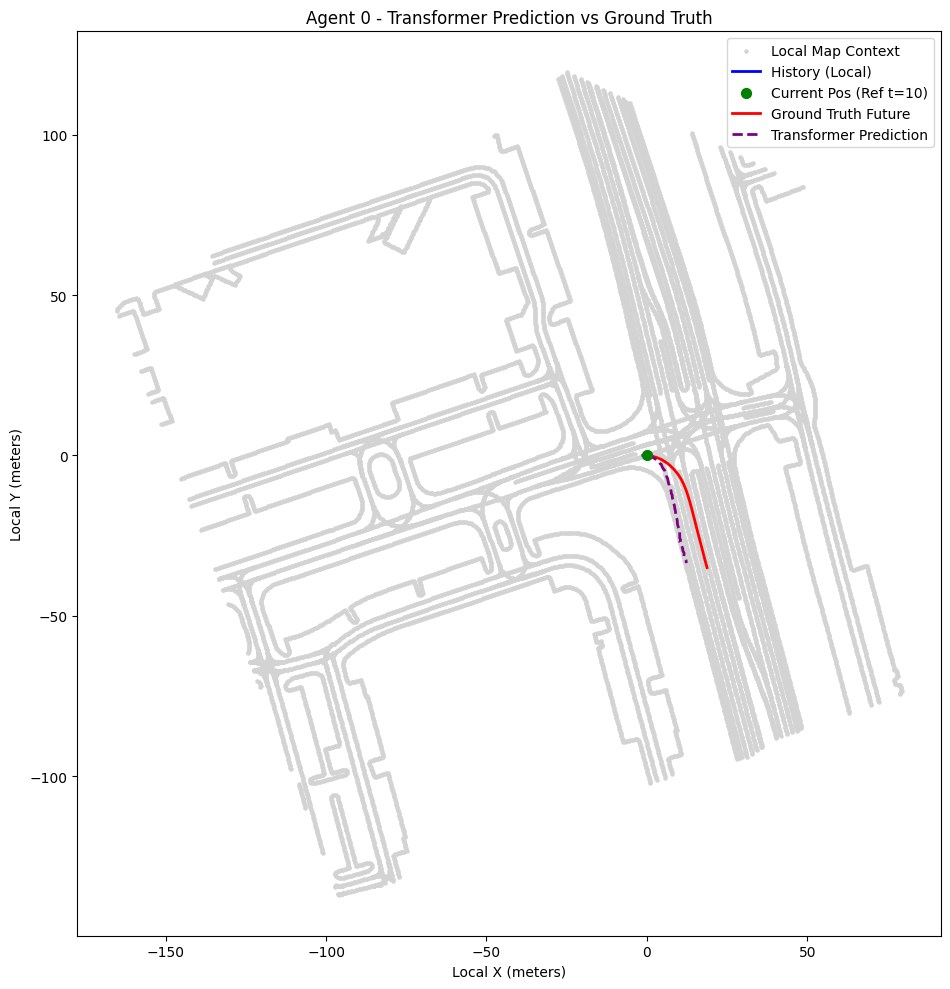

In [28]:
import matplotlib.pyplot as plt
import numpy as np

# Select the exact same target agent as the physics baselines (from training set)
target_agent_id = 0
agent_idx = list(df_training_ready['agent_id'].unique()).index(target_agent_id)

# 1. Prepare inputs for the SOTA model
hist_input = history_tensor_np[agent_idx:agent_idx+1]  # Shape: (1, 11, 7)

# Process map context exactly as the model expects (max 1000 points)
local_map_full = agent_centric_maps[target_agent_id]
local_map_model = local_map_full.copy()
max_map_points = 1000

if len(local_map_model) > max_map_points:
    dists = np.linalg.norm(local_map_model, axis=1)
    closest_idx = np.argsort(dists)[:max_map_points]
    local_map_model = local_map_model[closest_idx]
elif len(local_map_model) < max_map_points:
    pad_size = max_map_points - len(local_map_model)
    local_map_model = np.pad(local_map_model, ((0, pad_size), (0, 0)), mode='constant')

map_input = np.expand_dims(local_map_model, axis=0) # Shape: (1, 1000, 2)

# Generate prediction
preds = sota_model.predict({'history': hist_input, 'map_context': map_input}, verbose=0)
pred_fut_sota = preds[0]

# Extract ground truth & history for visualization
hist_traj = history_tensor_np[agent_idx, :, :2]  # local_x, local_y
ground_truth_fut = future_tensor_np[agent_idx, :, :2]

# Plotting
fig, ax = plt.subplots(figsize=(10, 10))

# Plot full local map context (using the un-truncated map for a complete picture)
ax.scatter(local_map_full[:, 0], local_map_full[:, 1], color='lightgray', s=5, label='Local Map Context')

# Plot historical trajectory
ax.plot(hist_traj[:, 0], hist_traj[:, 1], color='blue', linewidth=2, label='History (Local)')
ax.scatter(hist_traj[-1, 0], hist_traj[-1, 1], color='green', s=15, label='Current Pos (Ref t=10)', zorder=5)

# Plot ground truth future trajectory
ax.plot(ground_truth_fut[:, 0], ground_truth_fut[:, 1], color='red', linewidth=2, label='Ground Truth Future')

# Plot predicted future trajectory
ax.plot(pred_fut_sota[:, 0], pred_fut_sota[:, 1], color='purple', linestyle='--', linewidth=2, label='Transformer Prediction')

ax.set_title(f'Agent {target_agent_id} - Transformer Prediction vs Ground Truth')
ax.set_xlabel('Local X (meters)')
ax.set_ylabel('Local Y (meters)')
ax.set_aspect('equal')
ax.legend()

plt.tight_layout()
plt.show()


In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Select the exact same target agent as the physics baselines (from training set)
target_agent_id = 0
agent_idx = list(df_training_ready['agent_id'].unique()).index(target_agent_id)

# 1. Prepare inputs for the SOTA model
hist_input = history_tensor_np[agent_idx:agent_idx+1]  # Shape: (1, 11, 7)

# Process map context exactly as the model expects (max 1000 points)
local_map_full = agent_centric_maps[target_agent_id]
local_map_model = local_map_full.copy()
max_map_points = 1000

if len(local_map_model) > max_map_points:
    dists = np.linalg.norm(local_map_model, axis=1)
    closest_idx = np.argsort(dists)[:max_map_points]
    local_map_model = local_map_model[closest_idx]
elif len(local_map_model) < max_map_points:
    pad_size = max_map_points - len(local_map_model)
    local_map_model = np.pad(local_map_model, ((0, pad_size), (0, 0)), mode='constant')

map_input = np.expand_dims(local_map_model, axis=0) # Shape: (1, 1000, 2)

# Generate prediction
preds = sota_model.predict({'history': hist_input, 'map_context': map_input}, verbose=0)
pred_fut_sota = preds[0]

# Extract ground truth & history for visualization
hist_traj = history_tensor_np[agent_idx, :, :2]  # local_x, local_y
ground_truth_fut = future_tensor_np[agent_idx, :, :2]

# Plotting
fig, ax = plt.subplots(figsize=(10, 10))

# Plot full local map context (using the un-truncated map for a complete picture)
ax.scatter(local_map_full[:, 0], local_map_full[:, 1], color='lightgray', s=5, label='Local Map Context')

# Plot historical trajectory
ax.plot(hist_traj[:, 0], hist_traj[:, 1], color='blue', linewidth=2, label='History (Local)')
ax.scatter(hist_traj[-1, 0], hist_traj[-1, 1], color='green', s=15, label='Current Pos (Ref t=10)', zorder=5)

# Plot ground truth future trajectory
ax.plot(ground_truth_fut[:, 0], ground_truth_fut[:, 1], color='red', linewidth=2, label='Ground Truth Future')

# Plot predicted future trajectory
ax.plot(pred_fut_sota[:, 0], pred_fut_sota[:, 1], color='purple', linestyle='--', linewidth=2, label='Transformer Prediction')

ax.set_title(f'Agent {target_agent_id} - Transformer Prediction vs Ground Truth')
ax.set_xlabel('Local X (meters)')
ax.set_ylabel('Local Y (meters)')
ax.set_aspect('equal')
ax.legend()

plt.tight_layout()
plt.show()


NameError: name 'df_training_ready' is not defined